# Extension: Mixed-effects model for repeated IQ measurements

This notebook complements `stats_python.ipynb` by fitting a mixed-effects model on the long-format FSIQ/PIQ data. The main notebook uses ordinary least squares, which treats each IQ row as independent and matches the independent-groups comparison. Here we add random intercepts for participants because each person contributes two correlated IQ scores.

## Why account for repeated measurements?

FSIQ and PIQ are measured on the **same participants**, so the two rows per person are not independent. Ignoring the pairing can misestimate uncertainty and produce misleading inference when comparing measurement types. A mixed-effects model with a random intercept for each participant allows the two scores to correlate within person while still estimating the mean difference between PIQ and FSIQ. This is a sensible extension when the goal is inference about within-subject IQ contrasts rather than a deliberately independent-groups specification.

## Setup and load data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf

data = pd.read_csv('brain_size.csv', sep=';', na_values='.')
data = data.rename(columns={'Unnamed: 0': 'Participant'})

## Visualizing within-participant pairing

Each line in the figure below represents one participant and connects that person's full-scale IQ (FSIQ) and performance IQ (PIQ) scores. Because both points come from the same individual, the plot illustrates the repeated-measurement structure used by the mixed-effects model: some participants show similar scores across the two measures, while others show larger within-person shifts. This within-participant pairing motivates the random-intercept extension beyond treating the two IQ rows as independent observations.

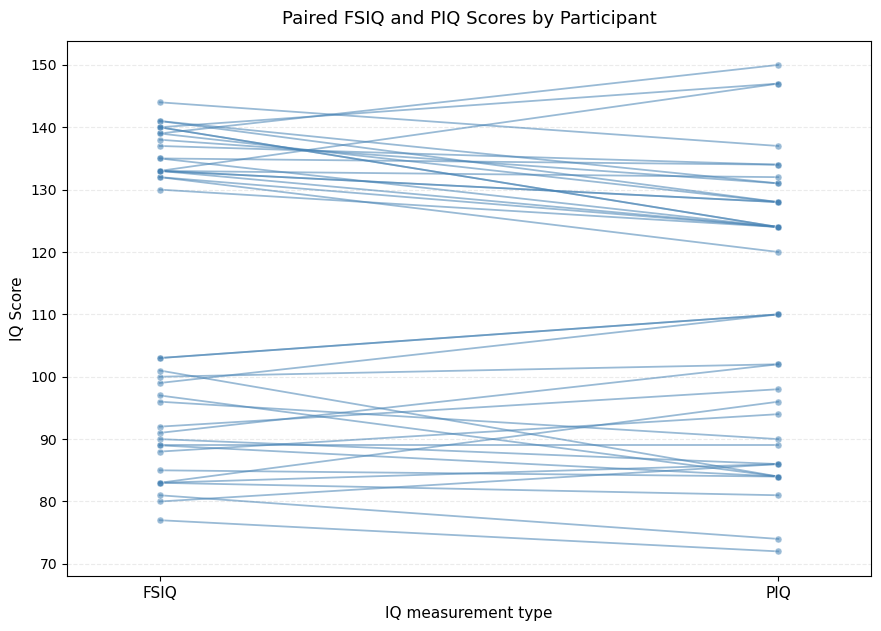

In [2]:
iq_pair_data = data[['Participant', 'FSIQ', 'PIQ']].dropna()
x_positions = [0, 1]
x_labels = ['FSIQ', 'PIQ']

fig, ax = plt.subplots(figsize=(9, 6.5))

for _, row in iq_pair_data.iterrows():
    ax.plot(
        x_positions,
        [row['FSIQ'], row['PIQ']],
        color='steelblue',
        alpha=0.55,
        linewidth=1.3,
        marker='o',
        markersize=5,
        markerfacecolor='steelblue',
        markeredgecolor='white',
        markeredgewidth=0.6,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_xlabel('IQ measurement type', fontsize=11)
ax.set_ylabel('IQ Score', fontsize=11)
ax.set_title('Paired FSIQ and PIQ Scores by Participant', fontsize=13, pad=12)
ax.set_xlim(-0.15, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.25)
fig.subplots_adjust(left=0.1, right=0.97, top=0.92, bottom=0.12)
plt.tight_layout(pad=1.4)
plt.show()

## Long-format IQ data and mixed-effects model

In [3]:
fsiq_piq_long = (
    data[['Participant', 'FSIQ', 'PIQ']]
    .melt(
        id_vars='Participant',
        value_vars=['FSIQ', 'PIQ'],
        var_name='IQ measurement type',
        value_name='IQ value',
    )
)

print('First rows of the long-format IQ table:')
display(fsiq_piq_long.head(8))

iq_mixed_model = smf.mixedlm(
    'Q("IQ value") ~ C(Q("IQ measurement type"))',
    data=fsiq_piq_long,
    groups=fsiq_piq_long['Participant'],
).fit()

print(iq_mixed_model.summary())

piq_coef_name = 'C(Q("IQ measurement type"))[T.PIQ]'
print(
    f'\nReference measurement type: FSIQ. The PIQ coefficient '
    f'({iq_mixed_model.params[piq_coef_name]:.2f}) is the estimated mean difference '
    f'PIQ − FSIQ, accounting for repeated measurements within participants.'
)

print(
    "\nInterpretation: PIQ is estimated to be about 2.43 points lower than FSIQ "
    f"(coefficient = {iq_mixed_model.params[piq_coef_name]:.2f}; p = "
    f"{iq_mixed_model.pvalues[piq_coef_name]:.3f}). This difference is not "
    "statistically significant at the 0.05 level. The participant random intercept "
    "accounts for repeated measurements from the same individuals."
)

First rows of the long-format IQ table:


,Participant,IQ measurement type,IQ value
0,1,FSIQ,133
1,2,FSIQ,140
2,3,FSIQ,139
3,4,FSIQ,133
4,5,FSIQ,137
5,6,FSIQ,99
6,7,FSIQ,138
7,8,FSIQ,92


                     Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Q("IQ value")
No. Observations:        80             Method:                    REML         
No. Groups:              40             Scale:                     36.9459      
Min. group size:         2              Log-Likelihood:            -320.3649    
Max. group size:         2              Converged:                 Yes          
Mean group size:         2.0                                                    
--------------------------------------------------------------------------------
                                    Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------
Intercept                          113.450    3.683 30.807 0.000 106.232 120.668
C(Q("IQ measurement type"))[T.PIQ]  -2.425    1.359 -1.784 0.074  -5.089   0.239
Group Var                          505.500   27.60